Using device: cpu


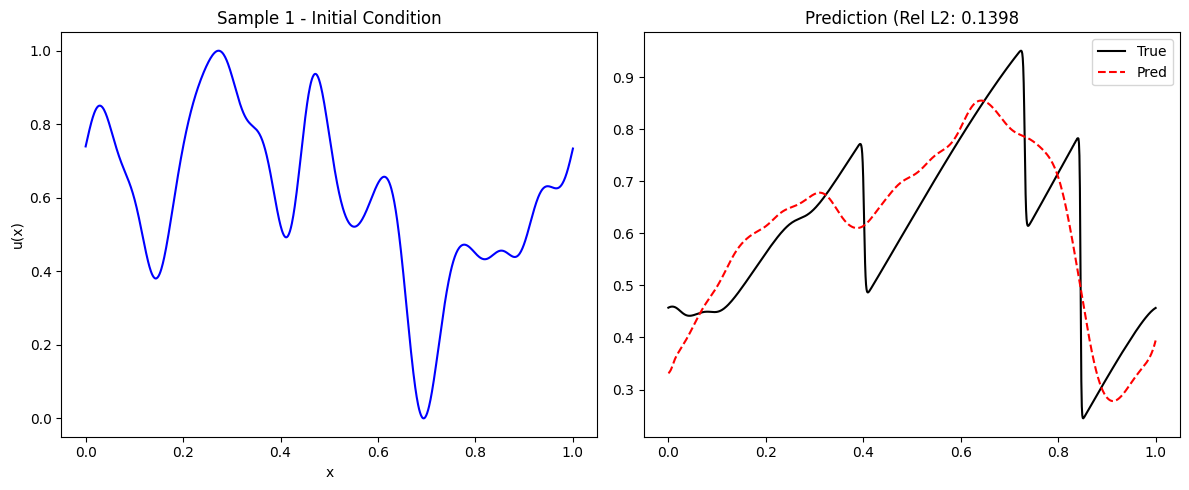

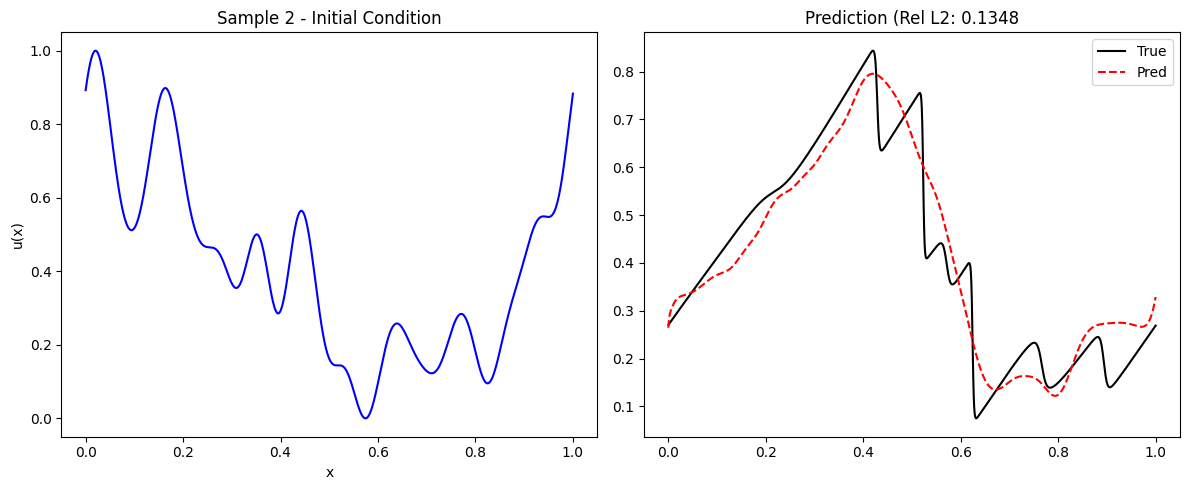

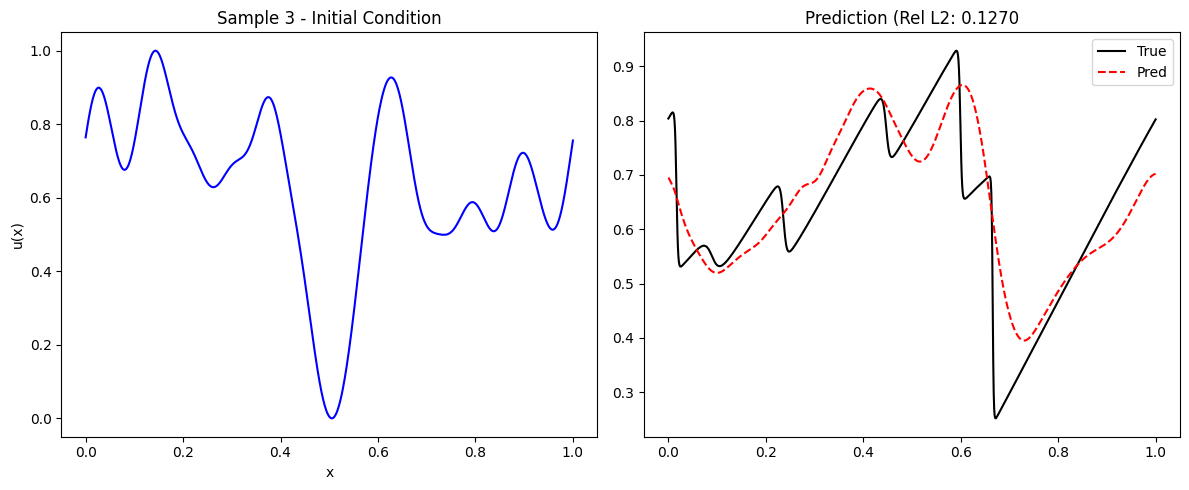

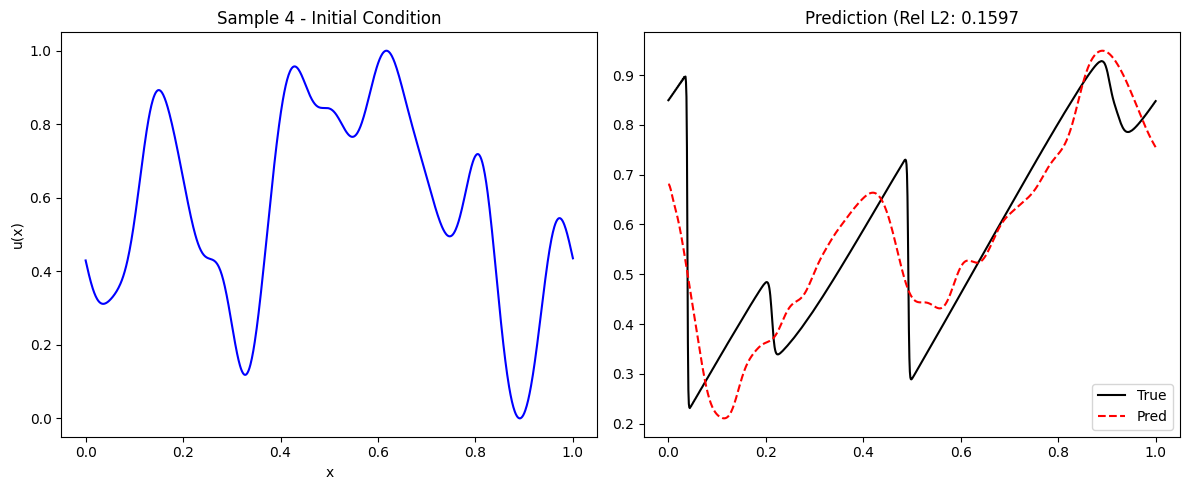

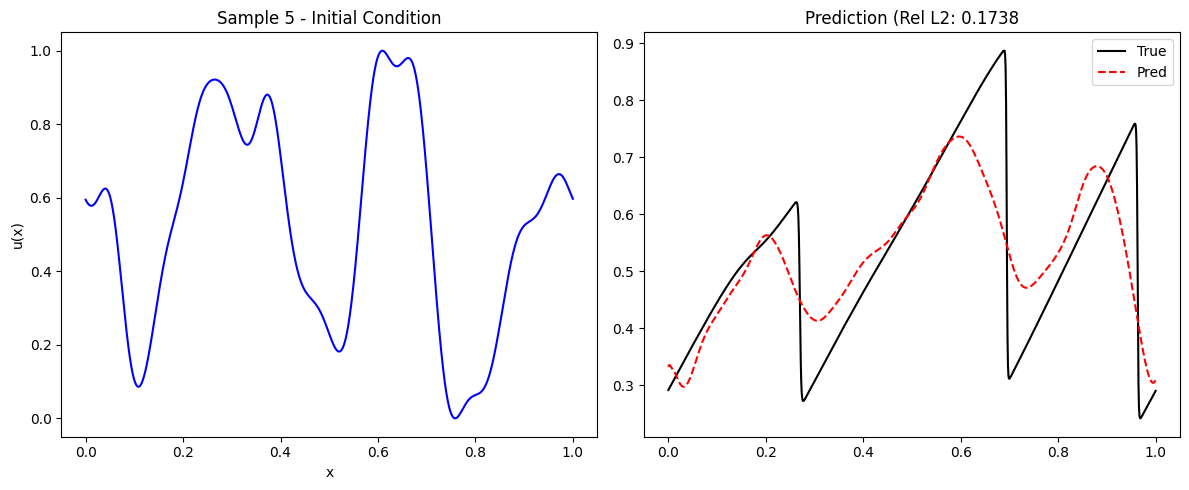

In [3]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 设备设置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DeepONet(torch.nn.Module):
    def __init__(self, branch_input_dim, trunk_input_dim, hidden_dim):  # 注意参数名必须匹配
        super().__init__()
        self.branch_net = torch.nn.Sequential(
            torch.nn.Linear(branch_input_dim, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.GELU()
        )
        self.trunk_net = torch.nn.Sequential(
            torch.nn.Linear(1, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.GELU()
        )
        
    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)
        trunk_out = self.trunk_net(trunk_input.view(-1, 1))
        return torch.bmm(
            trunk_out.view(branch_input.size(0), -1, trunk_input.size(1)),
            branch_out.unsqueeze(1).transpose(1, 2)
        ).squeeze(-1)

def load_model(model_path):
    """加载模型并自动解析参数"""
    model_path = Path(model_path).absolute()
    print(f"模型文件路径: {model_path}")
    
    if not model_path.exists():
        raise FileNotFoundError(f"❌ 模型文件不存在: {model_path}")

    # 从父目录名解析参数
    parent_dir = model_path.parent.name
    print(f"父目录名: {parent_dir}")
    
    try:
        parts = parent_dir.split('_')
        assert len(parts) >= 7, "目录名格式不完整"
        
        params = {
            'branch_input_dim': int(parts[1][1:]),
            'trunk_input_dim': int(parts[2][1:]),
            'hidden_dim': int(parts[3][1:])
        }
        
        assert all(v > 0 for v in params.values()), "网络维度必须为正整数"
        
    except Exception as e:
        raise ValueError(
            f"❌ 目录名解析失败: {parent_dir}\n"
            f"要求格式: DeepONet_b[分支维度]_t[主干维度]_h[隐藏层维度]_...\n"
            f"示例: DeepONet_b1024_t1024_h1024_lr0.001_bs100_ep500"
        ) from e

    # 初始化模型
    model = DeepONet(
        branch_input_dim=params['branch_input_dim'],
        trunk_input_dim=params['trunk_input_dim'],
        hidden_dim=params['hidden_dim']
    )
    
    # 关键修复：自动处理CPU/GPU兼容加载
    if torch.cuda.is_available():
        model.load_state_dict(torch.load(model_path))
        model = model.cuda()
    else:
        model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        model = model.cpu()
    
    model.eval()
    print(f"✅ 模型加载成功! 设备: {next(model.parameters()).device}")
    return model, params



def load_test_data(data_path, device):
    """加载测试数据集"""
    test_data = torch.load(data_path)
    test_a = test_data["x"].to(device)  # 初始条件 [N, 1024]
    test_u = test_data["y"].to(device)  # 真实解 [N, 1024]
    
    # 创建空间网格 [0,1]区间
    grid = torch.linspace(0, 1, test_a.shape[1], device=device).unsqueeze(0).unsqueeze(-1)
    test_grid = grid.repeat(test_a.size(0), 1, 1)  # [N, 1024, 1]
    
    return test_a, test_u, test_grid

def visualize_results(model, test_a, test_u, test_grid, num_samples=3):
    """推理并可视化结果"""
    with torch.no_grad():
        preds = model(test_a, test_grid)
    
    x_coord = torch.linspace(0, 1, test_a.shape[1]).cpu().numpy()
    
    for idx in range(min(num_samples, test_a.size(0))):
        plt.figure(figsize=(12, 5))
        
        # 初始条件
        plt.subplot(1, 2, 1)
        plt.plot(x_coord, test_a[idx].cpu(), 'b-')
        plt.title(f"Sample {idx+1} - Initial Condition")
        plt.xlabel("x"); plt.ylabel("u(x)")
        
        # 预测对比
        plt.subplot(1, 2, 2)
        plt.plot(x_coord, test_u[idx].cpu(), 'k-', label='True')
        plt.plot(x_coord, preds[idx].cpu(), 'r--', label='Pred')
        
        rel_error = torch.norm(preds[idx]-test_u[idx])/torch.norm(test_u[idx])
        plt.title(f"Prediction (Rel L2: {rel_error:.4f}")
        plt.legend()
        
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # 1. 加载模型 (使用您训练保存的best_model.pt)
    model_path = "best_model.pt"
    model = DeepONet(branch_input_dim=1024, trunk_input_dim=1024, hidden_dim=1024).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. 加载测试数据
    test_data_path = "../../../../datasets/nu0.0005/dim1d_nx1024_N100_test.pt"  # 请确认路径
    test_a, test_u, test_grid = load_test_data(test_data_path, device)
    
    # 3. 推理和可视化
    visualize_results(model, test_a, test_u, test_grid, num_samples=5)

Using device: cpu


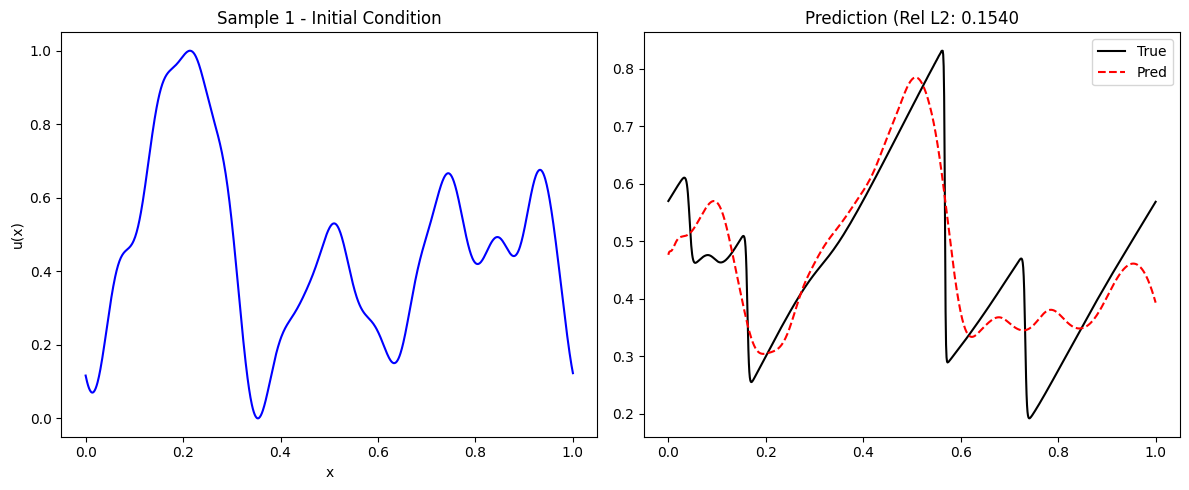

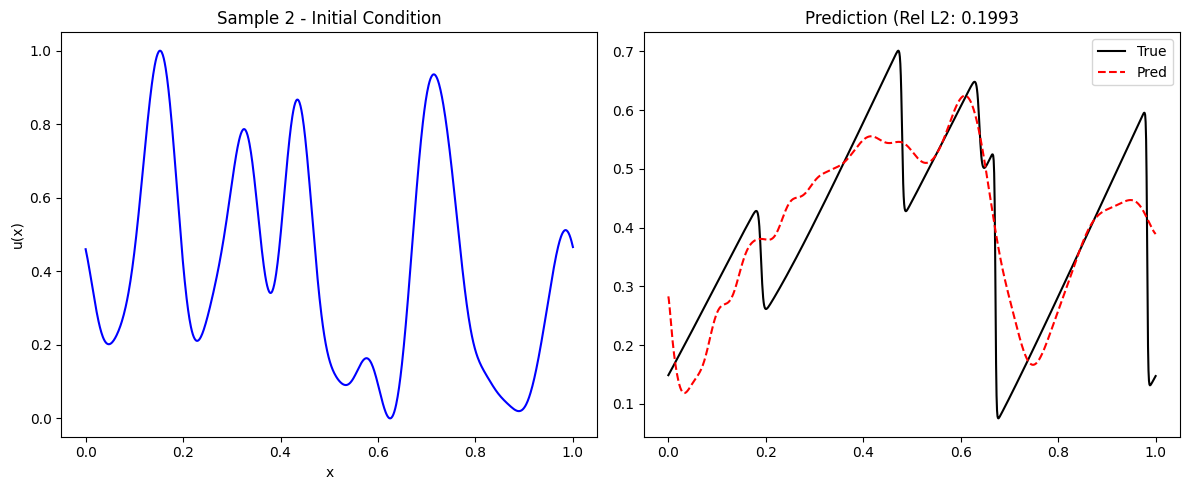

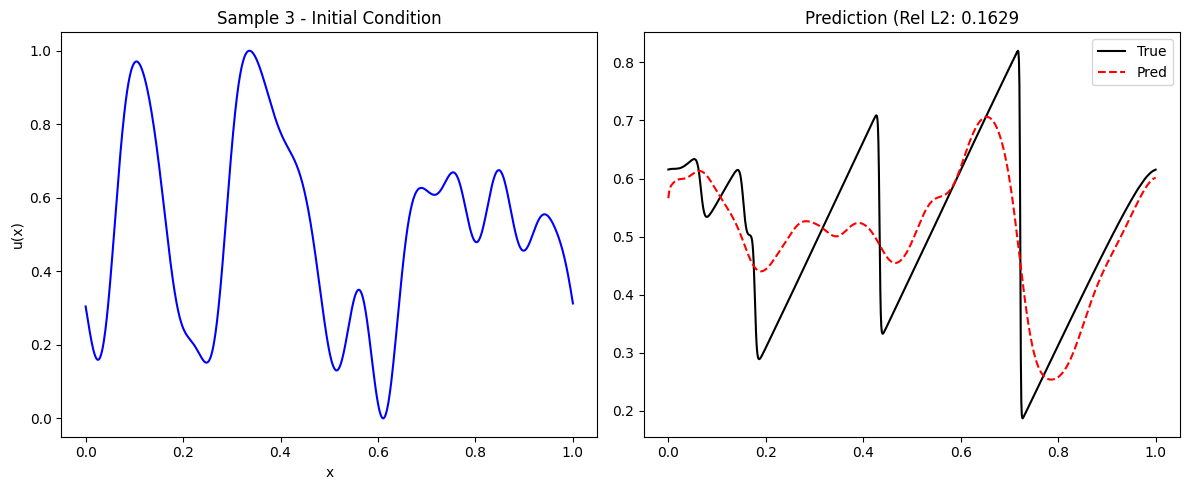

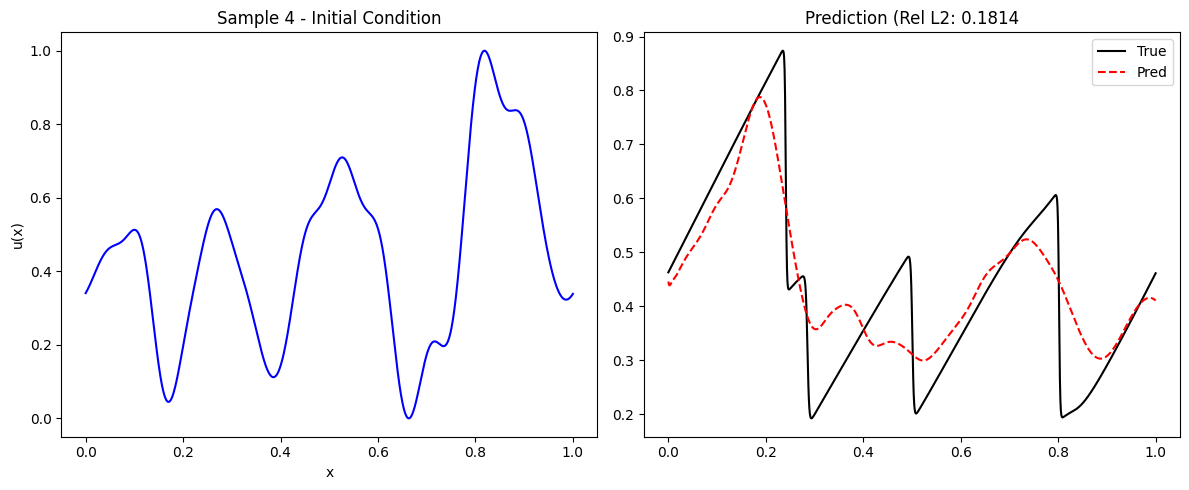

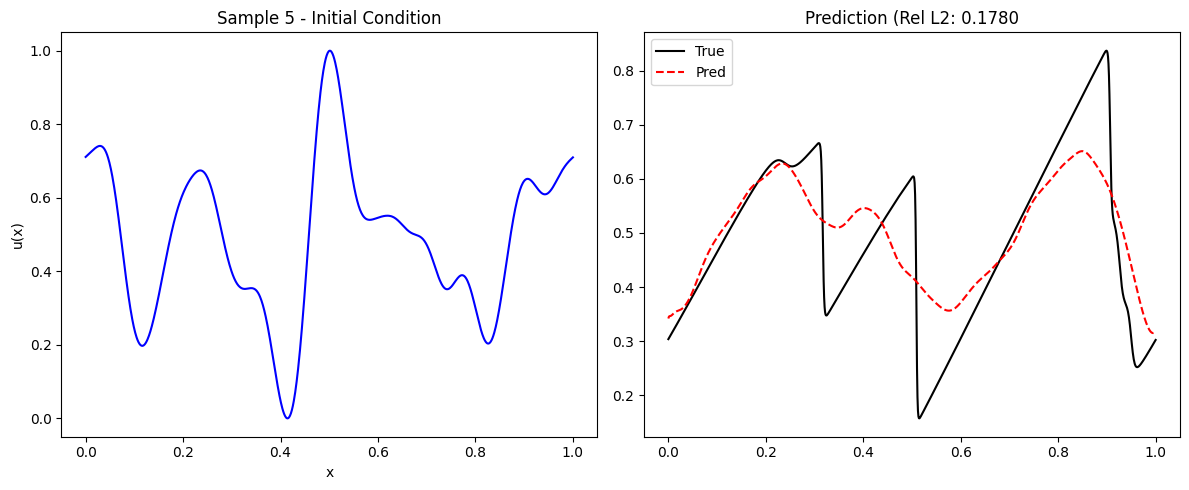

In [4]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 设备设置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DeepONet(torch.nn.Module):
    def __init__(self, branch_input_dim, trunk_input_dim, hidden_dim):  # 注意参数名必须匹配
        super().__init__()
        self.branch_net = torch.nn.Sequential(
            torch.nn.Linear(branch_input_dim, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.GELU()
        )
        self.trunk_net = torch.nn.Sequential(
            torch.nn.Linear(1, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.GELU()
        )
        
    def forward(self, branch_input, trunk_input):
        branch_out = self.branch_net(branch_input)
        trunk_out = self.trunk_net(trunk_input.view(-1, 1))
        return torch.bmm(
            trunk_out.view(branch_input.size(0), -1, trunk_input.size(1)),
            branch_out.unsqueeze(1).transpose(1, 2)
        ).squeeze(-1)

def load_model(model_path):
    """加载模型并自动解析参数"""
    model_path = Path(model_path).absolute()
    print(f"模型文件路径: {model_path}")
    
    if not model_path.exists():
        raise FileNotFoundError(f"❌ 模型文件不存在: {model_path}")

    # 从父目录名解析参数
    parent_dir = model_path.parent.name
    print(f"父目录名: {parent_dir}")
    
    try:
        parts = parent_dir.split('_')
        assert len(parts) >= 7, "目录名格式不完整"
        
        params = {
            'branch_input_dim': int(parts[1][1:]),
            'trunk_input_dim': int(parts[2][1:]),
            'hidden_dim': int(parts[3][1:])
        }
        
        assert all(v > 0 for v in params.values()), "网络维度必须为正整数"
        
    except Exception as e:
        raise ValueError(
            f"❌ 目录名解析失败: {parent_dir}\n"
            f"要求格式: DeepONet_b[分支维度]_t[主干维度]_h[隐藏层维度]_...\n"
            f"示例: DeepONet_b1024_t1024_h1024_lr0.001_bs100_ep500"
        ) from e

    # 初始化模型
    model = DeepONet(
        branch_input_dim=params['branch_input_dim'],
        trunk_input_dim=params['trunk_input_dim'],
        hidden_dim=params['hidden_dim']
    )
    
    # 关键修复：自动处理CPU/GPU兼容加载
    if torch.cuda.is_available():
        model.load_state_dict(torch.load(model_path))
        model = model.cuda()
    else:
        model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
        model = model.cpu()
    
    model.eval()
    print(f"✅ 模型加载成功! 设备: {next(model.parameters()).device}")
    return model, params



def load_test_data(data_path, device):
    """加载测试数据集"""
    test_data = torch.load(data_path)
    test_a = test_data["x"].to(device)  # 初始条件 [N, 1024]
    test_u = test_data["y"].to(device)  # 真实解 [N, 1024]
    
    # 创建空间网格 [0,1]区间
    grid = torch.linspace(0, 1, test_a.shape[1], device=device).unsqueeze(0).unsqueeze(-1)
    test_grid = grid.repeat(test_a.size(0), 1, 1)  # [N, 1024, 1]
    
    return test_a, test_u, test_grid

def visualize_results(model, test_a, test_u, test_grid, num_samples=3):
    """推理并可视化结果"""
    with torch.no_grad():
        preds = model(test_a, test_grid)
    
    x_coord = torch.linspace(0, 1, test_a.shape[1]).cpu().numpy()
    
    for idx in range(min(num_samples, test_a.size(0))):
        plt.figure(figsize=(12, 5))
        
        # 初始条件
        plt.subplot(1, 2, 1)
        plt.plot(x_coord, test_a[idx].cpu(), 'b-')
        plt.title(f"Sample {idx+1} - Initial Condition")
        plt.xlabel("x"); plt.ylabel("u(x)")
        
        # 预测对比
        plt.subplot(1, 2, 2)
        plt.plot(x_coord, test_u[idx].cpu(), 'k-', label='True')
        plt.plot(x_coord, preds[idx].cpu(), 'r--', label='Pred')
        
        rel_error = torch.norm(preds[idx]-test_u[idx])/torch.norm(test_u[idx])
        plt.title(f"Prediction (Rel L2: {rel_error:.4f}")
        plt.legend()
        
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # 1. 加载模型 (使用您训练保存的best_model.pt)
    model_path = "best_model.pt"
    model = DeepONet(branch_input_dim=1024, trunk_input_dim=1024, hidden_dim=1024).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. 加载测试数据
    test_data_path = "../../../../datasets/nu0.0005/dim1d_nx1024_N1400_train.pt"  # 请确认路径
    test_a, test_u, test_grid = load_test_data(test_data_path, device)
    
    # 3. 推理和可视化
    visualize_results(model, test_a, test_u, test_grid, num_samples=5)